In [1]:
import numpy as np
import pandas as pd
from math import e
import matplotlib.pyplot as plt
np.random.seed(42)
print("라이브러리 import 완료")

라이브러리 import 완료


In [2]:
# 온도, 습도, 정답 데이터를 직접 만듭니다.
# 외부 파일을 읽지 않고, 코드 안에서 값을 그대로 정의합니다.
#
# 구조를 다시 확인 합니다
# 낮은 구간(온도 10~15) -> y=0
# 중간 구간(온도 22~28) -> y=1 <- 가운데 구간만 1
# 높은 구간(온도 35~38) -> y=0
data = {
    "temperature": [10, 15, 20, 25, 30, 35],
    "humidity":    [30, 40, 50, 60, 70, 80],
    "y":           [ 0,  0,  1,  1,  1,  0]
}

df = pd.DataFrame(data)
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,20,50,1
3,25,60,1
4,30,70,1
5,35,80,0


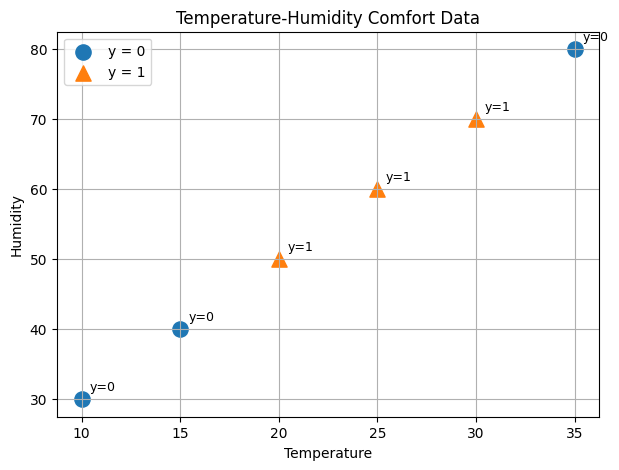

In [3]:
# 그림(figure) 하나를 만듭니다.
plt.figure(figsize=(7, 5))

# y=0 인 점과 y=1 인 점을 나누어 서로 다른 marker로 그립니다.
# boolean indexing: df["y"] == 0 인 행만 골라냅니다.
mask0 = df["y"] == 0    # y가 0인 행 (쾌적하지 않음)
mask1 = df["y"] == 1    # y가 1인 행 (쾌적함)

# y=0 그룹: marker='o' (동그라미)
plt.scatter(df.loc[mask0, "temperature"], df.loc[mask0, "humidity"],
                    marker="o", s=120, label="y = 0")

# y=1 그룹: marker='^' (동그라미)
plt.scatter(df.loc[mask1, "temperature"], df.loc[mask1, "humidity"],
                    marker="^", s=120, label="y = 1")

# 각 점 옆 y 값을 작게 표시합니다.
# zip 으로 (온도, 습도, y) 를 한 줄씩 꺼내면서 텍스트를 붙입니다.
for temp, hum, yv in zip(df["temperature"], df["humidity"], df["y"]):
    plt.annotate(f"y={yv}", (temp, hum),
                    textcoords="offset points", xytext=(6, 6), fontsize=9)

# 축 라벨, 제목, 범례, 격자 설정
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature-Humidity Comfort Data")
plt.legend()
plt.grid(True)

plt.show()

In [4]:
# X_raw: 원본 입력값. 온도와 습도를 나란히 붙여 (행의수, 2) 모양으로 만듭니다.
#   shape = (n, 2) -> 열 0 = 온도, 열 1 = 습도
X_raw = df[["temperature", "humidity"]].to_numpy(dtype=float)

# y: 실제 정답. (n, 1) 모양의 세로 벡터로 만듭니다.
#
# reshape(-1, 1) 의 의미를 자세히 봅니다.
# - 첫 번째 값 -1 : "행 개수는 자동으로 맞춰라" 라는 뜻입니다.
#                   (전체 개수를 보고 NumPy 가 알아서 행 수를 계산합니다)
# - 두 번째 값 1 : "열은 1개로 만들어라" 라는 뜻입니다.
# 즉 reshape(-1, 1) 은 값들을 (n, 1) 모양의 '세로 벡터' 로 세우라는 뜻입니다.
# 이렇게 y, z, H 를 모두 (n, 1) 모양으로 맞추면, 곱셈/뺄셈 계산이 어긋나지 않고 안전합니다.
y = df["y"].to_numpy(dtype=float).reshape(-1, 1)

In [5]:
# X_mean: 각 입력 컬럼(온도, 습도)의 평균.
# axis=0 은 "열 방향으로 계산" = 컬럼별 평균 이라는 뜻입니다.
# keepdims=True로 (1, 2) 모양을 유지해 브로드캐스팅이 쉽게 되도록 합니다.
X_mean = X_raw.mean(axis=0, keepdims=True) # shape = (1, 2)

# X_std: 각 입력 컬럼의 표준편차.
X_std = X_raw.std(axis=0, keepdims=True) # shape = (1, 2)

# X_norm: 정규화된 입력값. (원본 - 평균) / 표준편차
# X_raw 는 (n, 2), X_mean/X_std 는 (1, 2) 이지만
# NumPy 브로드캐스팅 덕분에 컬럼별로 자동 계산됩니다.
#
#[정규화를 왜, 어디에 쓰는지 정리]
# - 학습(gradient Descent)에는 정규화된 값 X_norm 을 사용합니다.
#     -> 온도(10~38)와 습도(30~80)처럼 범위가 다른 값을 그대로 넣으면 학습이 불안정하기 때문입니다.
# - 반대로 그래프와 결과 해석에는 원래 온도, 습도 단위(X_raw)를 사용합니다.
#     -> 사람은 "온도 25도, 습도 55%" 처럼 원래 단위가 훨씬 이해하기 쉽기 때문입니다.
# 즉, 컴퓨터 학습에는 정규화된 값이 안정적이고,
#    사람 해석에는 원래 단위가 편하므로, 둘을 목적에 맞게 나누어 씁니다.
X_norm = (X_raw - X_mean) / X_std # shape = (n, 2)

In [6]:
# 확인용으로 평균과 표준편차를 출력합니다.
print("X_mean (온도평균, 습도평균):", X_mean)
print("X_std  (온도표준편차, 습도표준편차):", X_std)
print("X_norm shape:", X_norm.shape)
print("y shape:", y.shape)

X_mean (온도평균, 습도평균): [[22.5 55. ]]
X_std  (온도표준편차, 습도표준편차): [[ 8.53912564 17.07825128]]
X_norm shape: (6, 2)
y shape: (6, 1)


In [7]:
# 정규화된 값을 DataFrame에 새 컬럼으로 추가해 원본과 함께 봅니다.
# 여기서는 표에 보기 좋게 넣기만 할 것이므로 (n,) 1차원 형태인 X_norm[:, 0] 을 사용합니다.
# (학습 코드에서는 y와 모양을 맞추려고 (n, 1) 형태인 X_norm[:, [0]]를 사용합니다. 뒤에서 다시 설명)
# 참고: (n,)와 (n, 1)은 모양이 다르며, 브로드캐스팅 방식이 달라져 계산 결과가 달라질 수 있으므로 목적에 맞게 구분해서 사용
df["temperature_norm"] = X_norm[:, 0]   # 정규화된 온도
df["humidity_norm"] = X_norm[:, 1]      # 정규화된 습도

df

,temperature,humidity,y,temperature_norm,humidity_norm
0,10,30,0,-1.46385,-1.46385
1,15,40,0,-0.87831,-0.87831
2,20,50,1,-0.29277,-0.29277
3,25,60,1,0.29277,0.29277
4,30,70,1,0.87831,0.87831
5,35,80,0,1.46385,1.46385


In [8]:
def sigmoid(H):
    # H 가 아주 크거나 아주 작으면 exp 계산에서 overflow(값이 너무 커짐)가 날 수 있습니다.
    # 그래서 H 를 -500 ~ 500 사이로 잘라(clip) 계산을 안정적으로 만듭니다.
    H_clip = np.clip(H, -500, 500)

    # sigmoid 공식: 1 / (1 + e^(-H))
    # 반환값 z는 항상 0과 1 사이의 예측 확률입니다.
    z = 1.0 / (1.0 + e**(-H_clip))

    return z

# 동작을 확인합니다.
# H=0이면 z=0.5, H가 크면 z는 1에 가까워지고, H가 작으면 z는 0에 가까워집니다.
print("sigmoid(0)  =", sigmoid(np.array(0.0)))
print("sigmoid(10)  =", sigmoid(np.array(10.0)))
print("sigmoid(-10)  =", sigmoid(np.array(-10.0)))

sigmoid(0)  = 0.5
sigmoid(10)  = 0.9999546021312976
sigmoid(-10)  = 4.539786870243442e-05


In [9]:
def bce_cost(y, z):
    # y: 실제 정답 (0 또는 1), z: 예측확률 (0~1)
    # epsilon: log(0) 을 피하기 위한 아주 작은 값
    # - log(0)은 무한대가 되어 Cost 계산이 불안정해집니다.
    # - epsilon은 수학적 의미를 바꾸는 값이 아니라, 계산 안정성을 위한 값입니다.
    epsilon = 1e-7

    # z를 [epsilon, 1-epsilon]범위로 잘라 log 계산을 안정적으로 만듭니다.
    z_clip = np.clip(z, epsilon, 1.0 - epsilon)

    # BCE 공식: -[y*log(z) + (1-y)*log(1-z)]
    # 각 데이터마다 cost 값이 나오므로, 평균(mean)을 내어 하나의 Cost로 만듭니다.
    cost = -(y * np.log(z_clip) + (1.0 - y) * np.log(1.0 - z_clip))

    # 반환값은 전체 데이터에 대한 '평균 Cost' 입니다.
    return np.mean(cost)

# 동작 확인: 정답과 예측이 비슷하면 Cost가 작고, 반대면 큽니다.
y_test = np.array([[1.0], [0.0]])
z_good = np.array([[0.9], [0.1]])   # 잘 맞춘 예측
z_bad  = np.array([[0.1], [0.9]])   # 크게 틀린 예측
print("잘 맞춘 경우의 Cost:", bce_cost(y_test, z_good))
print("크게 틀린 경우의 Cost:", bce_cost(y_test, z_bad))

잘 맞춘 경우의 Cost: 0.10536051565782628
크게 틀린 경우의 Cost: 2.302585092994046


In [10]:
# 정규화된 입력에서 온도 열과 습도 열을 각각 (n, 1) 세로 벡터로 꺼냅니다.
#
# [주의] X_norm[:, 0] 과 X_norm[:, [0]]은 모양(shape)이 다릅니다.
# - X_norm[:, 0] -> shape가 (n,) 인 1차원 배열 (가로로 늘어선 값)
# - X_norm[:, [0]] -> shape가 (n, 1) 인 2차원 세로 벡터 (열이 1개)
# 이번 노트북에서는 y 가 (n, 1) 모양이므로, 계산할 때 모양을 맞추기 위해
# 대괄호를 한 번 더 쓴 X_norm[:, [0]] (즉 (n, 1) 세로 벡터)를 사용합니다.
X1_norm = X_norm[:, [0]]    # 정규화된 온도, shape = (n, 1)
X2_norm = X_norm[:, [1]]    # 정규화된 습도, shape = (n, 1)

In [11]:
# 학습할 파라미터의 초기값. 모두 0에서 시작합니다.
a1 = 0.0    # 온도 가중치
a2 = 0.0    # 습도 가중치
b = 0.0     # 편향(bias)

# 학습 설정
learning_rate = 0.1 # 한 번에 얼마나 이동할지 정하는 값(너무 크면 발산, 너무 작으면 느림)
epochs = 10000      # 전체 데이터를 몇 번 반복 학습할지

# 학습 과정의 Cost를 저장할 리스트 (나중에 그래프로 그립니다)
cost_history = []

In [12]:
# 학습 반복 시작
# for epoch in range(epochs)는 '같은 데이터'를 여러 번(=epochs 번) 반복하면서
# 파라미터(a1, a2, b)를 조금씩 수정해 나가는 과정입니다.
for epoch in range(epochs):
    # 1.순전파: 선형 출력 H 계산 (H는 확률이 아님)
    H = a1 * X1_norm + a2 * X2_norm + b # shape = (n, 1)

    # 2.sigmoid로 예측확률 z계산 (z는 0~1)
    z = sigmoid(H)  # shape = (n, 1)

    # 3.Cost 계산 (평균BCE)
    cost = bce_cost(y, z)
    cost_history.append(cost)

    # 4.gradient 계산
    # BCE Cost와 sigmoid를 함께 미분하면 dCost/dH = (z - y)가 됩니다.
    # 이 값은 "지난 강의의 error = y - pred" 와는 다른, Cost를 미분해서 나온
    # gradient 신호이므로 이름을 grad_signal로 부릅니다. (자세한 설명은 위 마크다운 참고)
    # 각 가중치의 gradient는 grad_signal에 해당 입력을 곱해 평균을 냅니다.
    grad_signal = z - y     # 예측확률 - 실제값 (Cost 미분에서 나온 gradient 신호)
    grad_a1 = np.mean(grad_signal * X1_norm)    # a1 방향 gradient (np.mean은 전체 데이터의 평균 gradient)
    grad_a2 = np.mean(grad_signal * X2_norm)    # a2 방향 gradient
    grad_b = np.mean(grad_signal)               # b 방향 gradient

    # 5.파라미터 업데이트: 값 = 값 - learning_rate * gradient
    #   (gradient는 Cost가 증가하는 방향이므로 '빼서' Cost를 줄입니다)
    a1 = a1 - learning_rate * grad_a1
    a2 = a2 - learning_rate * grad_a2
    b = b - learning_rate * grad_b

    # 1000 epoch마다 진행 상황을 출력합니다.
    if epoch % 100 == 0:
        print(f"epoch {epoch:5d} | cost={cost:.6f} | a1={a1:.4f} | a2={a2:.4f} | b={b:.4f}")

epoch     0 | cost=0.693147 | a1=0.0146 | a2=0.0146 | b=0.0000
epoch   100 | cost=0.649174 | a1=0.3052 | a2=0.3052 | b=0.0000
epoch   200 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   300 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   400 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   500 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   600 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   700 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   800 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch   900 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1000 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1100 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1200 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1300 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1400 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1500 | cost=0.649169 | a1=0.3085 | a2=0.3

In [13]:
# 마지막 상태 출력
print("-" * 60)
print(f"학습 종료 | 최종 cost={cost_history[-1]:.6f}")
print(f"학습된 파라미터: a1={a1:.4f}, a2={a2:.4f}, b={b:.4f}")

------------------------------------------------------------
학습 종료 | 최종 cost=0.649169
학습된 파라미터: a1=0.3085, a2=0.3085, b=-0.0000
